# 🎮 Steam Games Dataset - Exploration & Analysis

dataset from kaggle: https://www.kaggle.com/datasets/fronkongames/steam-games-dataset

just exploring this dataset to see whats in it and what we can learn from it. this has data about games on steam - prices, reviews, genres, all that stuff.

## Setting things up

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from matplotlib import colormaps
import seaborn as sns
import warnings, os, ast

warnings.filterwarnings('ignore')

# --- plot style ---
# using a dark background because it looks cleaner for data viz
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#0e1117',
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#cccccc',
    'text.color': '#cccccc',
    'xtick.color': '#999999',
    'ytick.color': '#999999',
    'grid.color': '#1a1a2e',
    'grid.alpha': 0.4,
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.grid': True,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.titlepad': 15,
})

# color palette im going to use everywhere
COLORS = {
    'blue':    '#4fc3f7',
    'purple':  '#b388ff',
    'green':   '#69f0ae',
    'orange':  '#ffab40',
    'red':     '#ff5252',
    'teal':    '#64ffda',
    'pink':    '#ff80ab',
    'yellow':  '#ffd740',
    'cyan':    '#18ffff',
    'lime':    '#b2ff59',
    'gray':    '#78909c',
}
PAL = list(COLORS.values())

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

print('all good')

C:\Users\byogi\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


all good


## Downloading the dataset

In [2]:
path = kagglehub.dataset_download('fronkongames/steam-games-dataset')
print('downloaded to:', path)

for root, dirs, files in os.walk(path):
    for f in files:
        size = os.path.getsize(os.path.join(root, f)) / (1024*1024)
        print(f'  {f} - {size:.1f} MB')

downloaded to: C:\Users\byogi\.cache\kagglehub\datasets\fronkongames\steam-games-dataset\versions\40
  games.csv - 382.6 MB
  games.json - 871.9 MB


## Loading the data

In [3]:
csv_file = None
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith('.csv'):
            csv_file = os.path.join(root, f)

df = pd.read_csv(csv_file)
print(f'rows: {df.shape[0]:,}')
print(f'columns: {df.shape[1]}')
print(f'memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

rows: 125,855
columns: 39


memory: 591.3 MB


## First look at the data

In [4]:
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,NaN,0,252,3,NaN,0,231,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,NaN,0,21,3,NaN,0,0,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,yujingamesc@gmail.com,True,False,False,0,NaN,0,0,0,NaN,19,0,The game includes the following elements. 1. G...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125855 entries, 2539430 to 4247310
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       125854 non-null  object 
 1   Name                        125855 non-null  object 
 2   Release date                125855 non-null  object 
 3   Estimated owners            125855 non-null  int64  
 4   Peak CCU                    125855 non-null  int64  
 5   Required age                125855 non-null  float64
 6   Price                       125855 non-null  int64  
 7   DiscountDLC count           125855 non-null  int64  
 8   About the game              117393 non-null  object 
 9   Supported languages         125855 non-null  object 
 10  Full audio languages        125855 non-null  object 
 11  Reviews                     12181 non-null   object 
 12  Header image                125774 non-null  object 
 13  Website     

In [6]:
df.describe()

,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,Metacritic score,User score,Positive,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Movies
count,1.258550e+05,125855.000000,125855.000000,125855.000000,125855.000000,125855.000000,125855.000000,1.258550e+05,1.258550e+05,40.000000,125855.000000,1.258550e+05,1.258550e+05,125855.000000,1.258550e+05,125855.000000,0.0
mean,5.318720e+01,0.165365,4.811174,17.896826,0.535434,2.500083,0.023916,1.018182e+03,1.648786e+02,99.175000,17.922220,9.380399e+02,2.027568e+02,13.507711,1.691803e+02,14.419125,NaN
std,3.681083e+03,1.642666,12.489329,28.628518,14.328417,13.492922,1.376811,2.772782e+04,5.305001e+03,0.675107,139.696425,2.159585e+04,1.107222e+04,266.925759,1.105725e+04,290.747134,NaN
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
25%,0.000000e+00,0.000000,0.590000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,99.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
50%,0.000000e+00,0.000000,2.390000,0.000000,0.000000,0.000000,0.000000,4.000000e+00,1.000000e+00,99.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
75%,0.000000e+00,0.000000,5.545000,37.000000,0.000000,0.000000,0.000000,3.500000e+01,1.000000e+01,100.000000,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
max,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,100.000000,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,NaN


## Checking all the columns

lets see what each column has, how much data is missing, etc.

In [7]:
col_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'null_pct': round(df.isna().sum() / len(df) * 100, 1),
    'unique': df.nunique()
})
col_summary.sort_values('null_pct', ascending=False)

,dtype,non_null,null_pct,unique
Movies,float64,0,100.0,0
Score rank,float64,40,100.0,3
Metacritic url,object,4258,96.6,4162
Reviews,object,12181,90.3,11987
Notes,object,23310,81.5,19332
Website,object,50520,59.9,40353
Support url,object,55295,56.1,36161
Tags,object,83353,33.8,77184
Support email,object,103225,18.0,62321
Categories,object,116889,7.1,14058


ok so theres a lot of missing data in some columns. Movies is completely empty, Score rank is basically empty too. Reviews column is 90% missing.

also something weird - the 'Release date' column seems to have owner ranges in it? let me check.

In [8]:
print('Release date sample values:')
print(df['Release date'].value_counts())
print()
print('Estimated owners sample:')
print(df['Estimated owners'].value_counts().head(10))

Release date sample values:
Release date
0 - 20000                75705
0 - 0                    24579
20000 - 50000            11397
50000 - 100000            5355
100000 - 200000           3454
200000 - 500000           2856
500000 - 1000000          1155
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64

Estimated owners sample:
Estimated owners
0    106175
1      6529
2      2506
3      1428
4       931
5       693
6       555
7       389
8       371
9       282
Name: count, dtype: int64


yep, Release date has the owner ranges like '0 - 20000' and Estimated owners has the actual numbers. these column names are definitely swapped or something got messed up in the dataset.

## Cleaning the data

In [9]:
# dropping completely useless columns
df.drop(columns=['Movies', 'Score rank'], inplace=True)

# renaming the swapped columns
df.rename(columns={
    'Release date': 'Owner Range',
    'Estimated owners': 'Estimated Owners (num)'
}, inplace=True)

# adding useful derived columns
df['total_reviews'] = df['Positive'] + df['Negative']
df['positive_ratio'] = np.where(df['total_reviews'] > 0, df['Positive'] / df['total_reviews'], np.nan)
df['is_free'] = df['Price'] == 0
df['has_reviews'] = df['total_reviews'] > 0

def count_langs(val):
    try:
        langs = ast.literal_eval(val)
        return len(langs) if isinstance(langs, list) else 0
    except: return 0

df['lang_count'] = df['Supported languages'].apply(count_langs)

print(f'cleaned shape: {df.shape}')
print('added: total_reviews, positive_ratio, is_free, has_reviews, lang_count')

cleaned shape: (125855, 42)
added: total_reviews, positive_ratio, is_free, has_reviews, lang_count


## Missing data overview

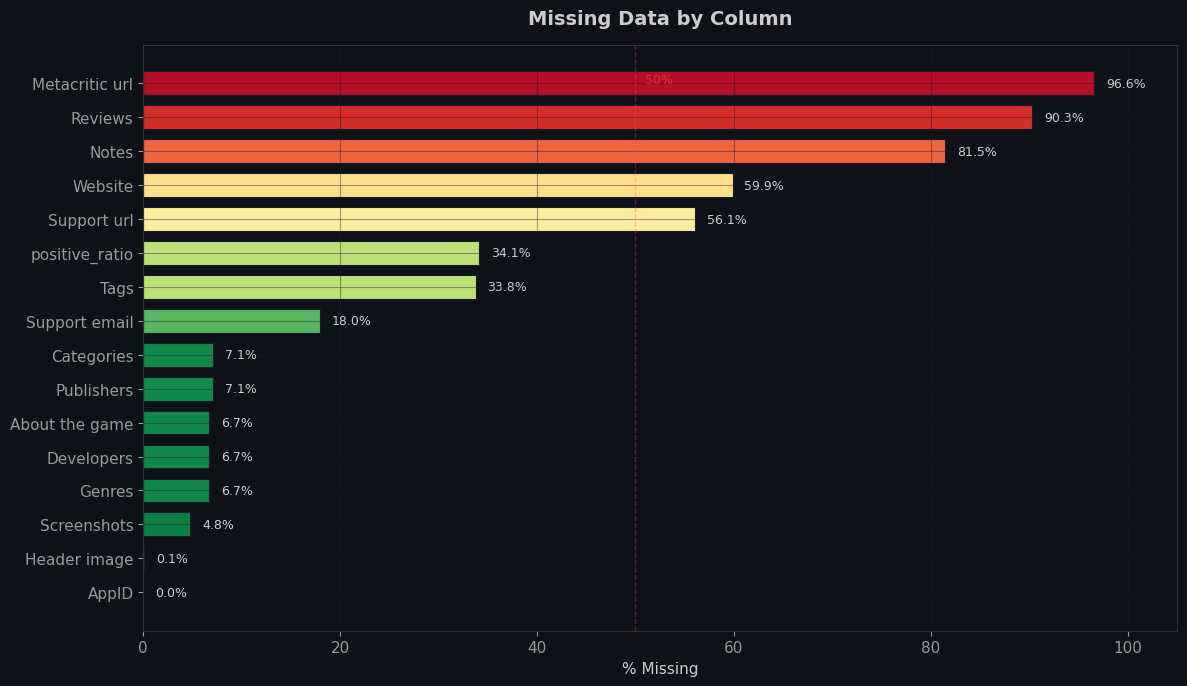

In [10]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(12, 7))

# color gradient based on severity
norm = plt.Normalize(0, 100)
cmap = colormaps.get_cmap('RdYlGn_r')
bar_colors = [cmap(norm(v)) for v in missing_pct.values]

bars = ax.barh(missing_pct.index, missing_pct.values, color=bar_colors,
               edgecolor='#1a1a2e', linewidth=0.8, height=0.7)
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Column')
ax.set_xlim(0, 105)

for i, (val, bar) in enumerate(zip(missing_pct.values, bars)):
    ax.text(val + 1.2, bar.get_y() + bar.get_height()/2,
           f'{val:.1f}%', va='center', fontsize=9, color='#cccccc')

ax.axvline(50, color='#ff5252', linestyle='--', alpha=0.3, linewidth=1)
ax.text(51, len(missing_pct)-1, '50%', color='#ff5252', alpha=0.5, fontsize=9)

plt.tight_layout()
plt.show()

## Platform analysis

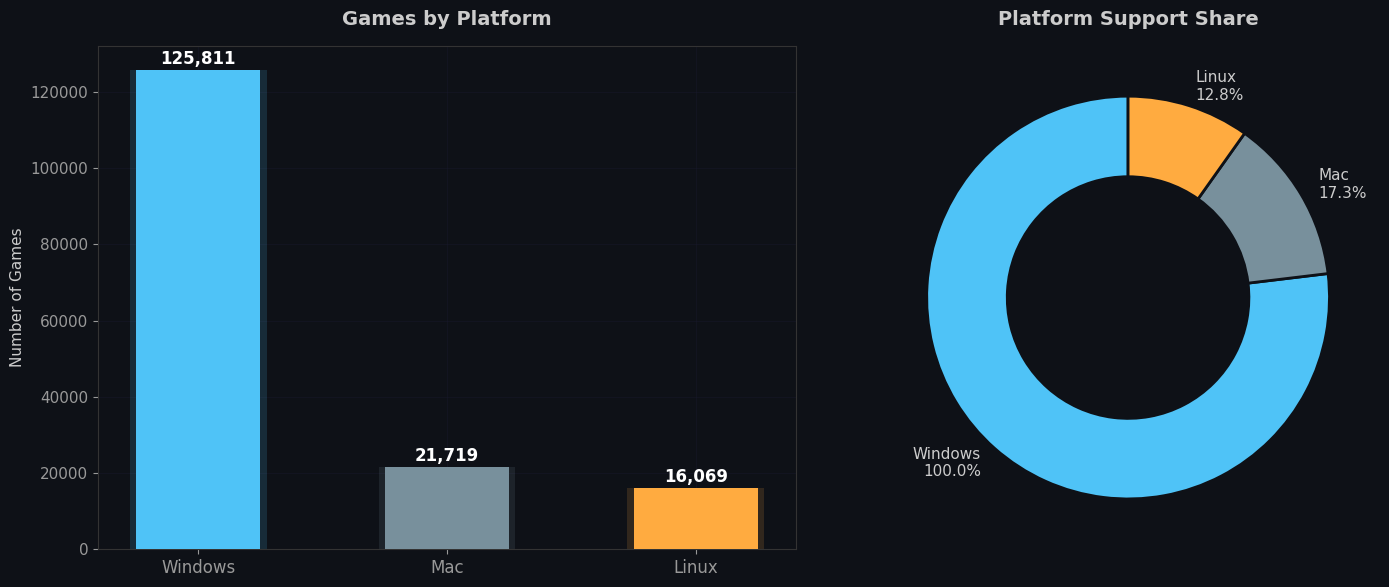

In [11]:
platform_data = {
    'Windows': df['Windows'].sum(),
    'Mac': df['Mac'].sum(),
    'Linux': df['Linux'].sum()
}
pcts = {k: v/len(df)*100 for k,v in platform_data.items()}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- left: bar chart with glow effect ---
platform_colors = [COLORS['blue'], COLORS['gray'], COLORS['orange']]
bars = axes[0].bar(platform_data.keys(), platform_data.values(),
                   color=platform_colors, edgecolor='none', width=0.5,
                   zorder=3)
# glow bars behind
for bar, color in zip(bars, platform_colors):
    axes[0].bar(bar.get_x() + bar.get_width()/2, bar.get_height(),
               width=0.55, alpha=0.15, color=color, zorder=2)

for bar, val in zip(bars, platform_data.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                f'{val:,}', ha='center', fontweight='bold', color='white', fontsize=12)
axes[0].set_title('Games by Platform')
axes[0].set_ylabel('Number of Games')
axes[0].tick_params(axis='x', labelsize=12)

# --- right: donut chart ---
sizes = list(pcts.values())
labels = [f'{k}\n{v:.1f}%' for k,v in pcts.items()]
wedges, texts = axes[1].pie(sizes, labels=labels, colors=platform_colors,
                            startangle=90, wedgeprops=dict(width=0.4, edgecolor='#0e1117', linewidth=2),
                            textprops={'color': '#cccccc', 'fontsize': 11})
axes[1].set_title('Platform Support Share')

plt.tight_layout()
plt.show()

basically everything supports windows (99.9%). mac and linux are way behind at ~17% and ~13%.

## Price analysis

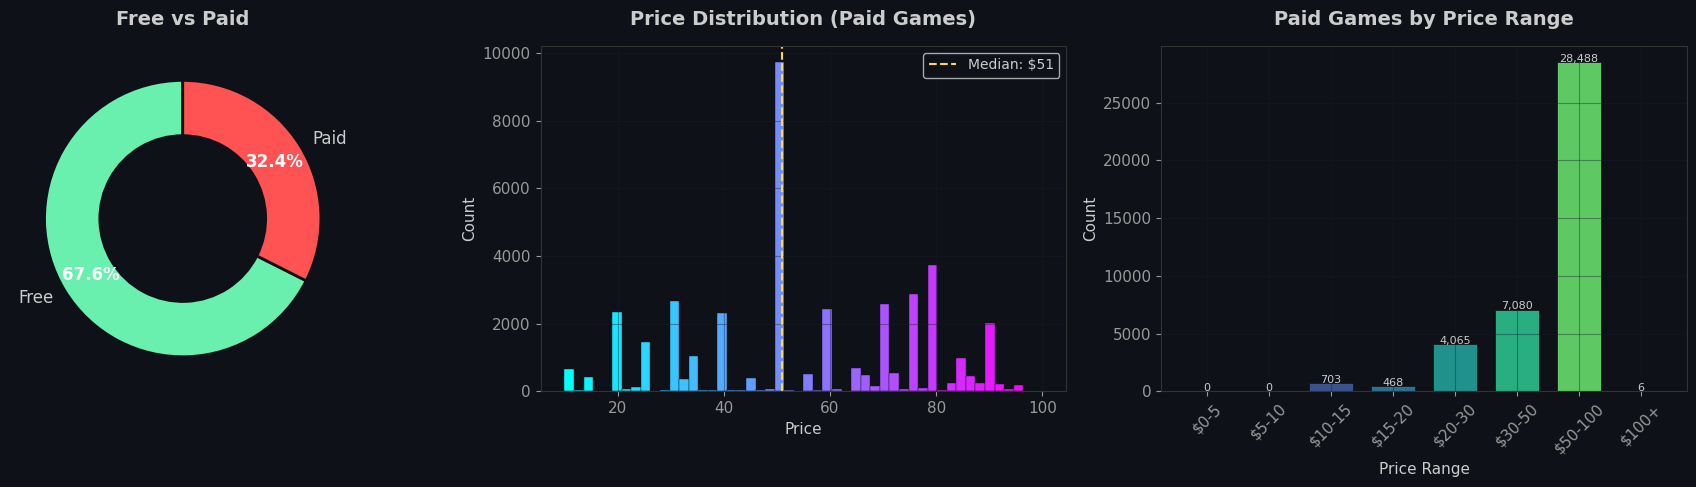

In [12]:
free_count = df['is_free'].sum()
paid_count = (~df['is_free']).sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- donut: free vs paid ---
donut_colors = [COLORS['green'], COLORS['red']]
wedges, texts, autotexts = axes[0].pie(
    [free_count, paid_count], labels=['Free', 'Paid'],
    autopct='%1.1f%%', colors=donut_colors, startangle=90,
    wedgeprops=dict(width=0.4, edgecolor='#0e1117', linewidth=2),
    textprops={'color': '#cccccc', 'fontsize': 12},
    pctdistance=0.78)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
axes[0].set_title('Free vs Paid')

# --- histogram: price distribution ---
paid_prices = df[df['Price'] > 0]['Price']
n, bins, patches = axes[1].hist(paid_prices, bins=50, edgecolor='#0e1117', linewidth=0.3)
# gradient coloring for the histogram bars
cm = colormaps.get_cmap('cool')
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - bin_centers.min()
col /= col.max()
for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c))
axes[1].set_title('Price Distribution (Paid Games)')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Count')
axes[1].axvline(paid_prices.median(), color=COLORS['yellow'], linestyle='--',
                linewidth=1.5, label=f'Median: ${paid_prices.median():.0f}')
axes[1].legend(fontsize=10)

# --- price range breakdown ---
price_bins = [0, 5, 10, 15, 20, 30, 50, 100, float('inf')]
price_labels = ['$0-5', '$5-10', '$10-15', '$15-20', '$20-30', '$30-50', '$50-100', '$100+']
paid_df = df[df['Price'] > 0].copy()
paid_df['price_range'] = pd.cut(paid_df['Price'], bins=price_bins, labels=price_labels, right=False)
price_dist = paid_df['price_range'].value_counts().sort_index()

bar_colors_gradient = [colormaps.get_cmap('viridis')(i/len(price_dist)) for i in range(len(price_dist))]
bars = axes[2].bar(price_dist.index, price_dist.values, color=bar_colors_gradient,
                   edgecolor='#0e1117', linewidth=0.5, width=0.7)
axes[2].set_title('Paid Games by Price Range')
axes[2].set_xlabel('Price Range')
axes[2].set_ylabel('Count')
for bar, val in zip(bars, price_dist.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
               f'{val:,}', ha='center', fontsize=8, color='#cccccc')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Review analysis

this is where it gets interesting

In [13]:
reviewed = df[df['has_reviews']].copy()
print(f'games with at least 1 review: {len(reviewed):,} out of {len(df):,} ({len(reviewed)/len(df)*100:.1f}%)')
print(f'games with zero reviews: {(~df["has_reviews"]).sum():,}')
print(f'average positive ratio: {reviewed["positive_ratio"].mean()*100:.1f}%')
print(f'median positive ratio: {reviewed["positive_ratio"].median()*100:.1f}%')

games with at least 1 review: 82,956 out of 125,855 (65.9%)
games with zero reviews: 42,899
average positive ratio: 75.8%
median positive ratio: 81.8%


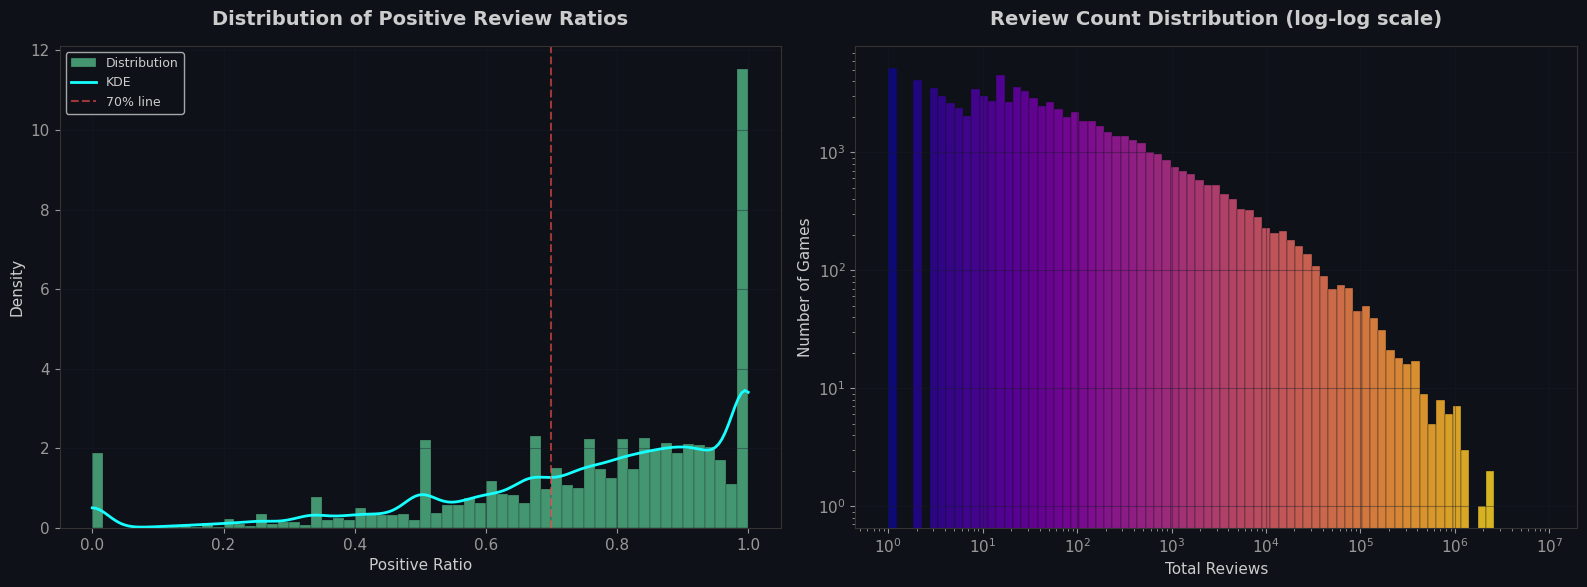

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: positive ratio distribution with KDE ---
ratios = reviewed['positive_ratio'].dropna()
axes[0].hist(ratios, bins=60, color=COLORS['green'], edgecolor='#0e1117',
             linewidth=0.3, alpha=0.6, density=True, label='Distribution')
# kde overlay
from scipy.stats import gaussian_kde
try:
    kde = gaussian_kde(ratios)
    x_kde = np.linspace(0, 1, 200)
    axes[0].plot(x_kde, kde(x_kde), color=COLORS['cyan'], linewidth=2, label='KDE')
except: pass
axes[0].axvline(0.7, color=COLORS['red'], linestyle='--', alpha=0.6, linewidth=1.5, label='70% line')
axes[0].set_title('Distribution of Positive Review Ratios')
axes[0].set_xlabel('Positive Ratio')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# --- right: review count (log-log) ---
review_counts = reviewed['total_reviews']
log_bins = np.logspace(0, np.log10(review_counts.max()), 80)
n, bins, patches = axes[1].hist(review_counts, bins=log_bins,
                                 edgecolor='#0e1117', linewidth=0.3, alpha=0.85)
# gradient color
cm = colormaps.get_cmap('plasma')
for i, p in enumerate(patches):
    plt.setp(p, 'facecolor', cm(i/len(patches)))
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Review Count Distribution (log-log scale)')
axes[1].set_xlabel('Total Reviews')
axes[1].set_ylabel('Number of Games')

plt.tight_layout()
plt.show()

In [15]:
# top 15 most reviewed games
top_reviewed = df.nlargest(15, 'total_reviews')[['Name', 'Positive', 'Negative', 'total_reviews', 'positive_ratio', 'Price', 'is_free']].copy()
top_reviewed['positive_ratio'] = (top_reviewed['positive_ratio'] * 100).round(1)
top_reviewed = top_reviewed.reset_index(drop=True)
top_reviewed.index = top_reviewed.index + 1
top_reviewed

,Name,Positive,Negative,total_reviews,positive_ratio,Price,is_free
1,"Aug 21, 2012",7642084,1173003,8815087,86.7,0,True
2,"Dec 21, 2017",1520457,1037487,2557944,59.4,0,True
3,"Jul 9, 2013",2037143,461826,2498969,81.5,0,True
4,"Apr 13, 2015",1739980,250576,1990556,87.4,0,True
5,"May 16, 2011",1373979,35494,1409473,97.5,50,False
6,"Dec 1, 2015",1172854,225730,1398584,83.9,0,True
7,"Feb 8, 2018",1071135,156649,1227784,87.2,50,False
8,"Oct 10, 2007",1044264,117208,1161472,89.9,0,True
9,"Nov 29, 2006",1122546,37161,1159707,96.8,50,False
10,"Aug 19, 2024",1111720,38378,1150098,96.7,0,True


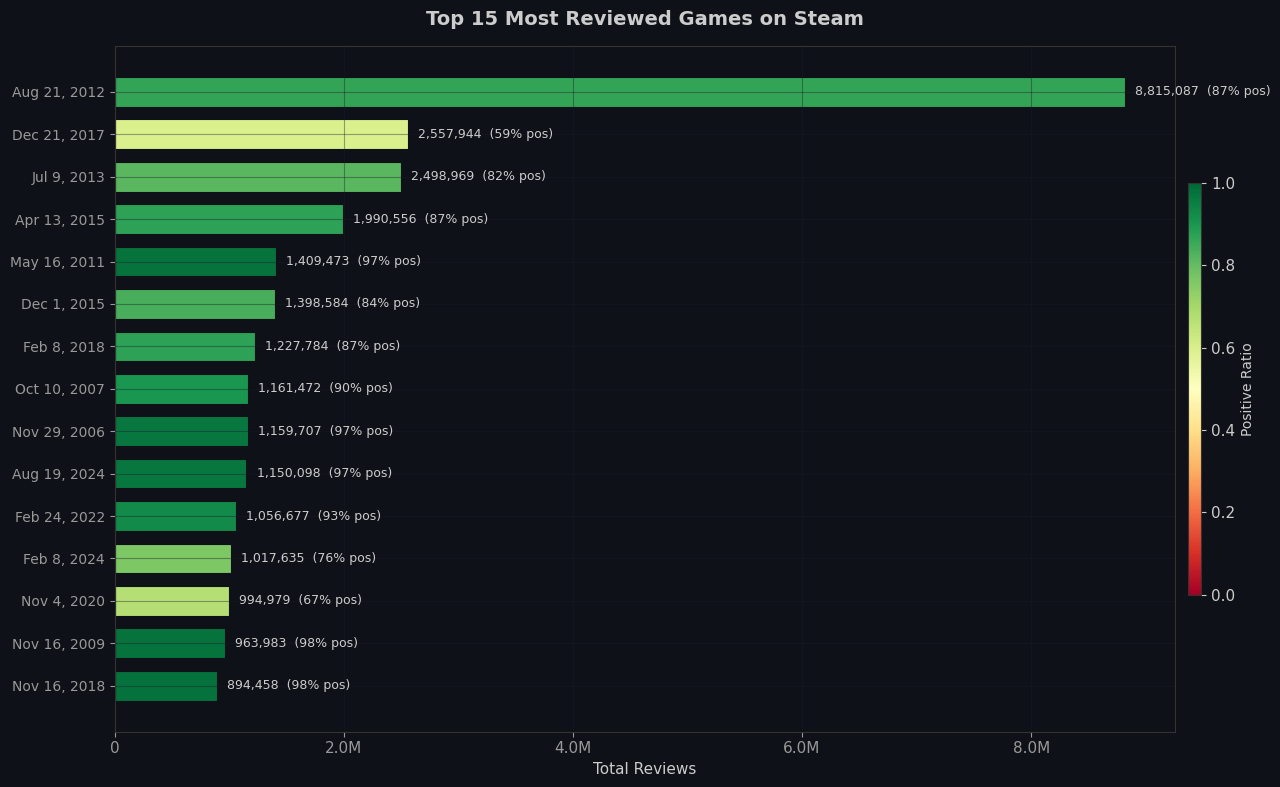

In [16]:
# horizontal bar chart of top 15 with color coded sentiment
fig, ax = plt.subplots(figsize=(14, 8))

top15 = df.nlargest(15, 'total_reviews').copy().sort_values('total_reviews')
names = top15['Name'].astype(str).str[:35]

# color bars by positive ratio (green=good, red=bad)
cmap = colormaps.get_cmap('RdYlGn')
bar_colors = [cmap(r) for r in top15['positive_ratio'].fillna(0.5)]

bars = ax.barh(range(len(names)), top15['total_reviews'], color=bar_colors,
               edgecolor='#0e1117', linewidth=0.8, height=0.7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel('Total Reviews')
ax.set_title('Top 15 Most Reviewed Games on Steam')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else str(int(x))))

for i, (val, ratio) in enumerate(zip(top15['total_reviews'], top15['positive_ratio'])):
    pct_text = f'{ratio*100:.0f}%' if not np.isnan(ratio) else '?'
    ax.text(val + top15['total_reviews'].max()*0.01, i,
            f'{val:,.0f}  ({pct_text} pos)', va='center', fontsize=9, color='#cccccc')

# colorbar legend
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
cbar = plt.colorbar(sm, ax=ax, pad=0.01, aspect=30, shrink=0.6)
cbar.set_label('Positive Ratio', fontsize=10, color='#cccccc')
cbar.ax.yaxis.set_tick_params(color='#cccccc')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#cccccc')

plt.tight_layout()
plt.show()

## Genre analysis

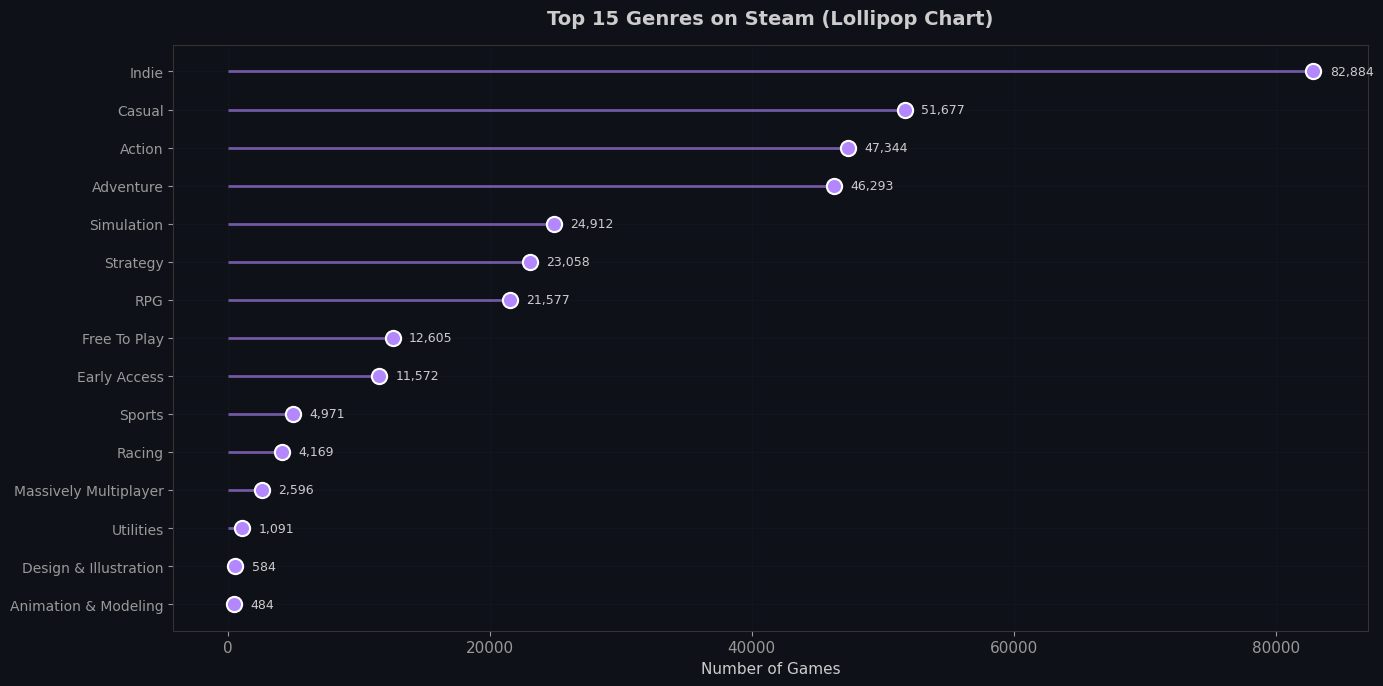

In [17]:
# splitting comma-separated genres
genre_exploded = df['Genres'].dropna().str.split(',').explode().str.strip()
genre_counts = genre_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 7))

# lollipop chart
y_pos = range(len(genre_counts))
vals = genre_counts.values[::-1]
labels = genre_counts.index[::-1]

# horizontal lines
ax.hlines(y=y_pos, xmin=0, xmax=vals, color=COLORS['purple'], alpha=0.6, linewidth=2)
# dots at the end
ax.scatter(vals, y_pos, color=COLORS['purple'], s=120, zorder=5, edgecolors='white', linewidth=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Number of Games')
ax.set_title('Top 15 Genres on Steam (Lollipop Chart)')

for i, val in enumerate(vals):
    ax.text(val + genre_counts.max()*0.015, i, f'{val:,}',
            va='center', fontsize=9, color='#cccccc')

plt.tight_layout()
plt.show()

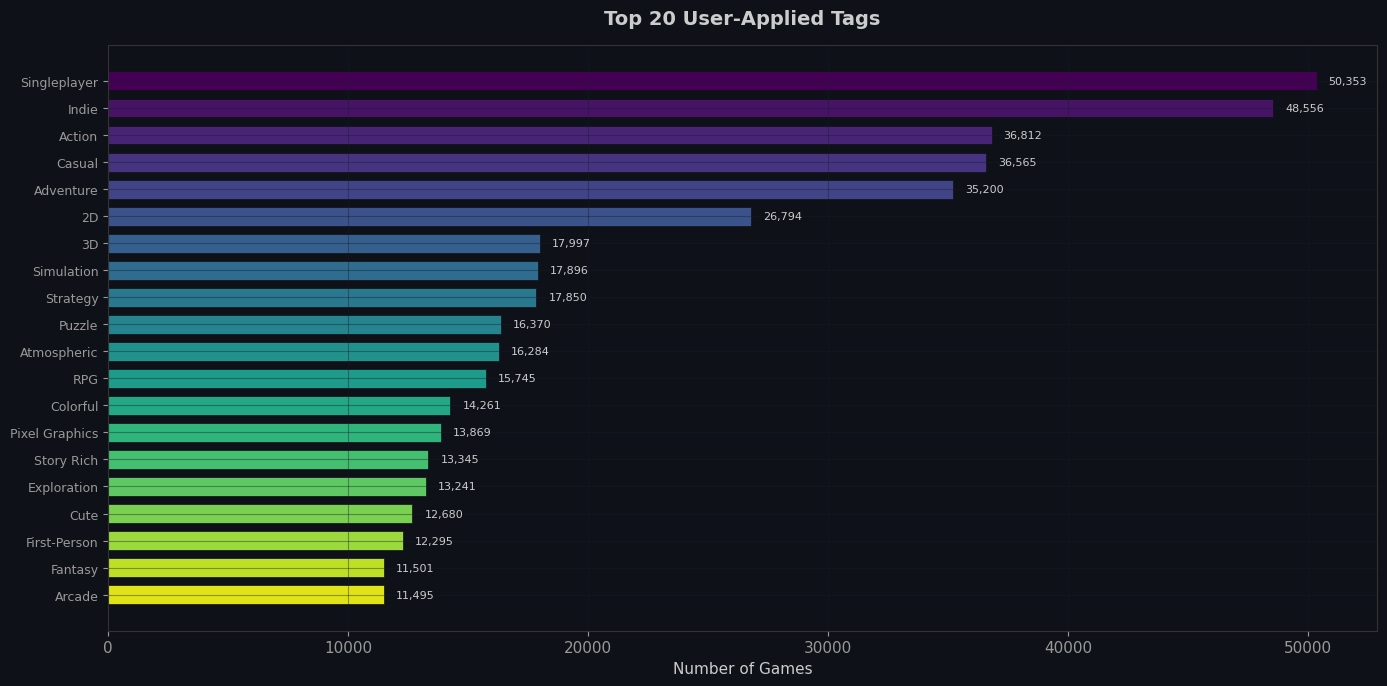

In [18]:
# tags - treemap style using nested bars
tag_exploded = df['Tags'].dropna().str.split(',').explode().str.strip()
tag_counts = tag_exploded.value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 7))

# gradient colored horizontal bars
cm = colormaps.get_cmap('viridis')
n_tags = len(tag_counts)
tag_colors = [cm(i/n_tags) for i in range(n_tags)]

y_pos = range(n_tags)
vals = tag_counts.values[::-1]
labels = tag_counts.index[::-1]
colors_rev = tag_colors[::-1]

bars = ax.barh(y_pos, vals, color=colors_rev, edgecolor='#0e1117',
               linewidth=0.5, height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Number of Games')
ax.set_title('Top 20 User-Applied Tags')

for i, val in enumerate(vals):
    ax.text(val + tag_counts.max()*0.01, i, f'{val:,}',
            va='center', fontsize=8, color='#cccccc')

plt.tight_layout()
plt.show()

## Free vs paid - which do better?

In [19]:
free_games = df[df['is_free']].copy()
paid_games = df[~df['is_free']].copy()
free_reviewed = free_games[free_games['has_reviews']]
paid_reviewed = paid_games[paid_games['has_reviews']]

comparison = pd.DataFrame({
    'Metric': ['Total Games', 'Games with Reviews', 'Avg Positive Ratio',
               'Median Total Reviews', 'Avg Peak CCU', 'Avg Achievements'],
    'Free': [
        len(free_games),
        len(free_reviewed),
        f"{free_reviewed['positive_ratio'].mean()*100:.1f}%",
        f"{free_reviewed['total_reviews'].median():.0f}",
        f"{free_games['Peak CCU'].mean():.1f}",
        f"{free_games['Achievements'].mean():.1f}"
    ],
    'Paid': [
        len(paid_games),
        len(paid_reviewed),
        f"{paid_reviewed['positive_ratio'].mean()*100:.1f}%",
        f"{paid_reviewed['total_reviews'].median():.0f}",
        f"{paid_games['Peak CCU'].mean():.1f}",
        f"{paid_games['Achievements'].mean():.1f}"
    ]
})
comparison

,Metric,Free,Paid
0,Total Games,85045,40810
1,Games with Reviews,49500,33456
2,Avg Positive Ratio,74.3%,78.0%
3,Median Total Reviews,16,51
4,Avg Peak CCU,0.1,0.3
5,Avg Achievements,13.2,27.8


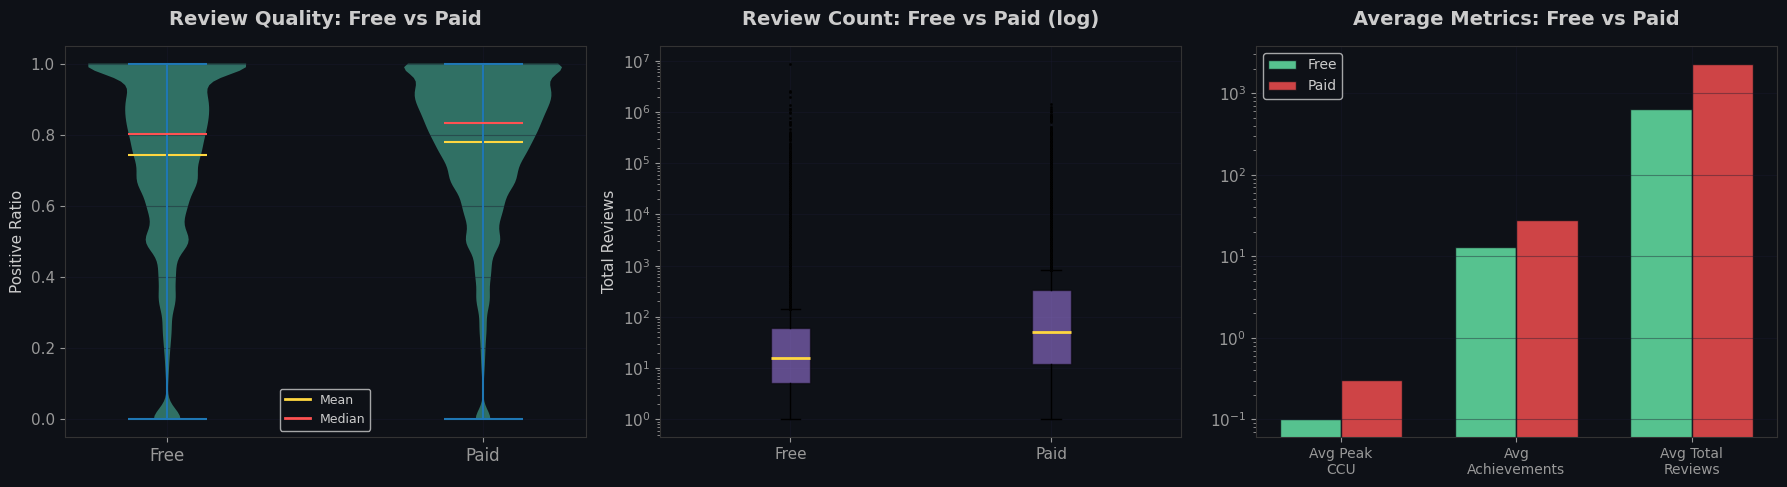

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- violin plot: positive ratios ---
free_r = free_reviewed['positive_ratio'].dropna()
paid_r = paid_reviewed['positive_ratio'].dropna()

parts = axes[0].violinplot([free_r, paid_r], positions=[1, 2], showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor(COLORS['teal'])
    pc.set_alpha(0.4)
parts['cmeans'].set_color(COLORS['yellow'])
parts['cmedians'].set_color(COLORS['red'])
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['Free', 'Paid'], fontsize=12)
axes[0].set_title('Review Quality: Free vs Paid')
axes[0].set_ylabel('Positive Ratio')

# custom legend for violin
axes[0].plot([], [], color=COLORS['yellow'], linewidth=2, label='Mean')
axes[0].plot([], [], color=COLORS['red'], linewidth=2, label='Median')
axes[0].legend(fontsize=9)

# --- box plot: review counts ---
bp = axes[1].boxplot([free_reviewed['total_reviews'], paid_reviewed['total_reviews']],
                     labels=['Free', 'Paid'], whis=1.5, patch_artist=True,
                     boxprops=dict(facecolor=COLORS['purple'], alpha=0.5),
                     medianprops=dict(color=COLORS['yellow'], linewidth=2),
                     flierprops=dict(marker='.', markersize=2, markerfacecolor=COLORS['gray']))
axes[1].set_yscale('log')
axes[1].set_title('Review Count: Free vs Paid (log)')
axes[1].set_ylabel('Total Reviews')

# --- grouped bar: avg metrics ---
metrics = ['Peak CCU', 'Achievements', 'total_reviews']
metric_labels = ['Avg Peak\nCCU', 'Avg\nAchievements', 'Avg Total\nReviews']
free_vals = [free_games[m].mean() for m in metrics]
paid_vals = [paid_games[m].mean() for m in metrics]

x = np.arange(len(metrics))
w = 0.35
bars1 = axes[2].bar(x - w/2, free_vals, w, label='Free', color=COLORS['green'], edgecolor='#0e1117', alpha=0.8)
bars2 = axes[2].bar(x + w/2, paid_vals, w, label='Paid', color=COLORS['red'], edgecolor='#0e1117', alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(metric_labels, fontsize=10)
axes[2].set_title('Average Metrics: Free vs Paid')
axes[2].legend(fontsize=10)
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

## Correlation heatmap

lets see which numerical columns are related to each other

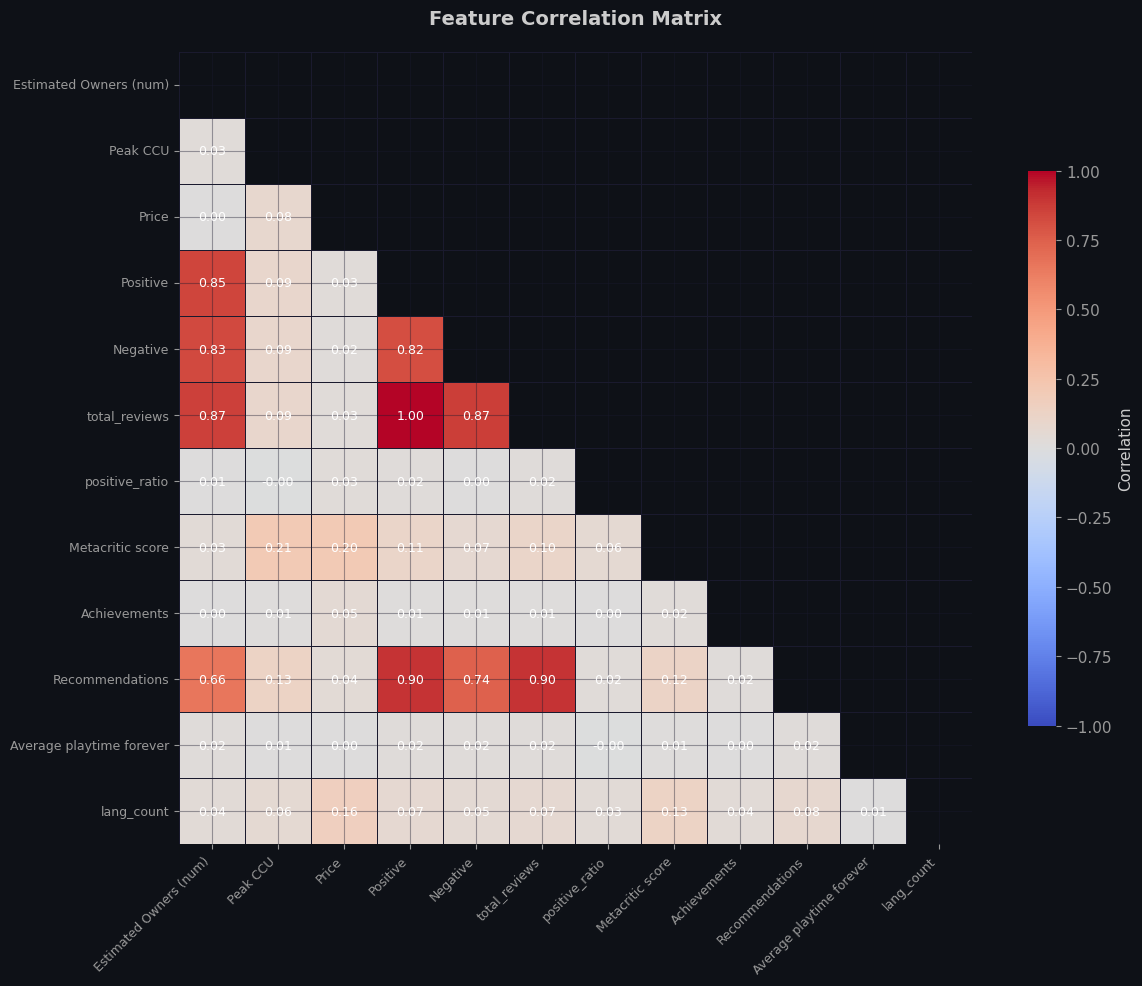

In [21]:
corr_cols = ['Estimated Owners (num)', 'Peak CCU', 'Price', 'Positive', 'Negative',
             'total_reviews', 'positive_ratio', 'Metacritic score',
             'Achievements', 'Recommendations', 'Average playtime forever', 'lang_count']
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, linecolor='#1a1a2e',
            ax=ax, cbar_kws={'shrink': 0.7, 'label': 'Correlation'},
            annot_kws={'size': 9, 'color': 'white'})

ax.set_title('Feature Correlation Matrix', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.show()

## Does price affect review quality?

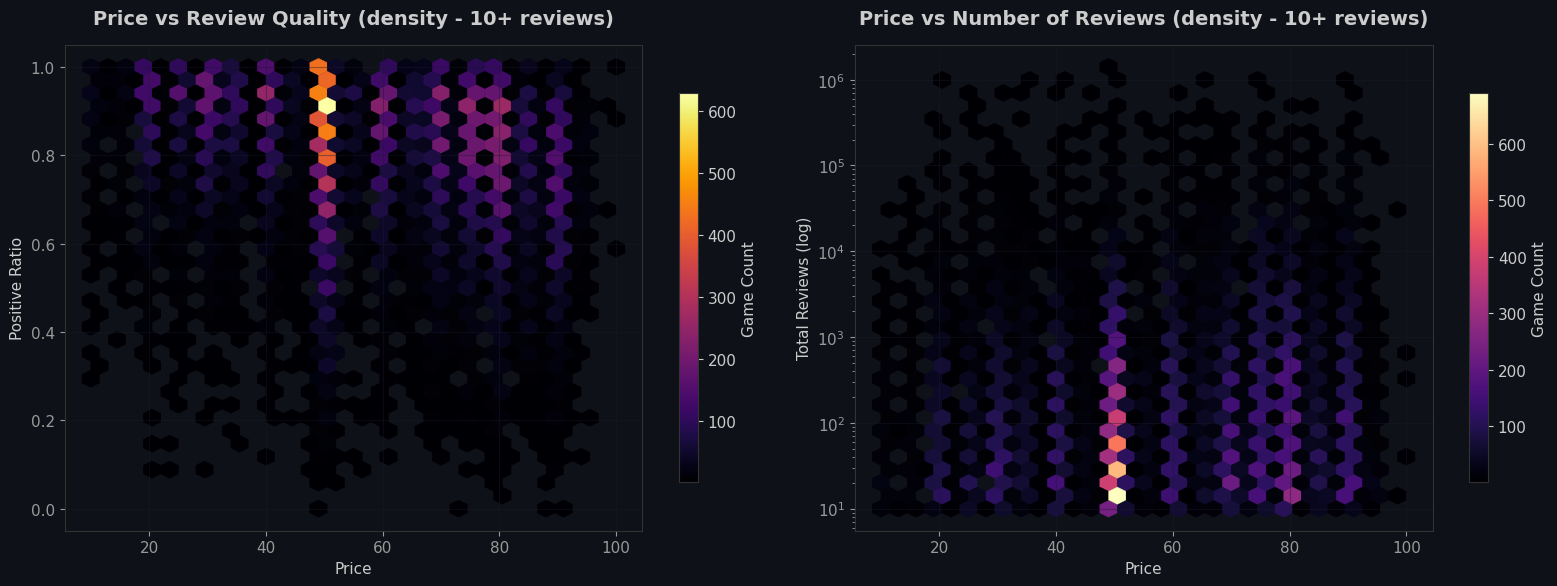

In [22]:
scatter_df = df[(df['total_reviews'] >= 10) & (df['Price'] > 0)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: price vs positive ratio (hexbin for density) ---
hb = axes[0].hexbin(scatter_df['Price'], scatter_df['positive_ratio'],
                     gridsize=30, cmap='inferno', mincnt=1, linewidths=0.2)
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Positive Ratio')
axes[0].set_title('Price vs Review Quality (density - 10+ reviews)')
cb = plt.colorbar(hb, ax=axes[0], shrink=0.8, label='Game Count')
cb.ax.yaxis.set_tick_params(color='#cccccc')
plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='#cccccc')

# --- right: price vs total reviews (log, with density coloring) ---
hb2 = axes[1].hexbin(scatter_df['Price'], scatter_df['total_reviews'],
                      gridsize=30, cmap='magma', mincnt=1, linewidths=0.2,
                      yscale='log')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Total Reviews (log)')
axes[1].set_title('Price vs Number of Reviews (density - 10+ reviews)')
cb2 = plt.colorbar(hb2, ax=axes[1], shrink=0.8, label='Game Count')
cb2.ax.yaxis.set_tick_params(color='#cccccc')
plt.setp(plt.getp(cb2.ax.axes, 'yticklabels'), color='#cccccc')

plt.tight_layout()
plt.show()

## The invisible majority

this is something i noticed and its actually really important

In [23]:
zero_reviews = (df['total_reviews'] == 0).sum()
zero_ccu = (df['Peak CCU'] == 0).sum()
zero_playtime = (df['Average playtime forever'] == 0).sum()
zero_owners = (df['Estimated Owners (num)'] == 0).sum()
total = len(df)

print('Games with ZERO engagement:')
print(f'  Zero reviews:       {zero_reviews:>7,} ({zero_reviews/total*100:.1f}%)')
print(f'  Zero peak CCU:      {zero_ccu:>7,} ({zero_ccu/total*100:.1f}%)')
print(f'  Zero avg playtime:  {zero_playtime:>7,} ({zero_playtime/total*100:.1f}%)')
print(f'  Zero est. owners:   {zero_owners:>7,} ({zero_owners/total*100:.1f}%)')

Games with ZERO engagement:
  Zero reviews:        42,899 (34.1%)
  Zero peak CCU:      124,567 (99.0%)
  Zero avg playtime:   99,682 (79.2%)
  Zero est. owners:   106,175 (84.4%)


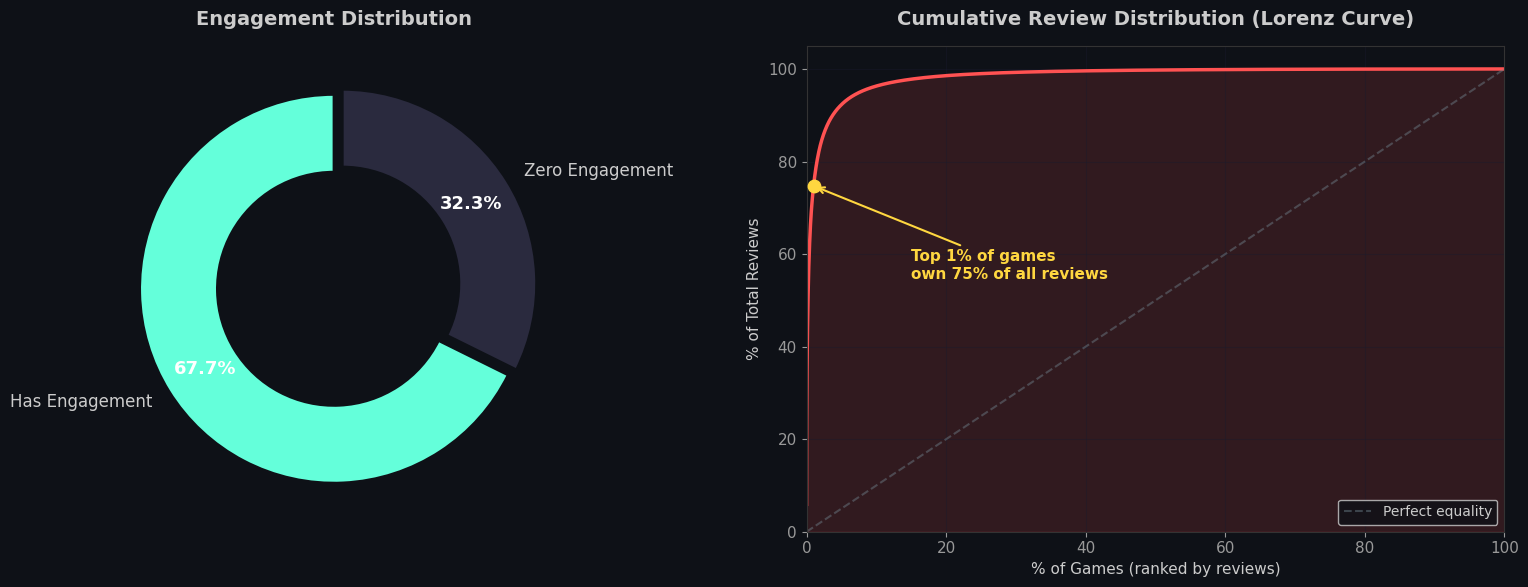

In [24]:
df['any_engagement'] = (
    (df['total_reviews'] > 0) |
    (df['Peak CCU'] > 0) |
    (df['Average playtime forever'] > 0)
)

engaged = df['any_engagement'].sum()
not_engaged = len(df) - engaged

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: donut ---
wedges, texts, autotexts = axes[0].pie(
    [engaged, not_engaged],
    labels=['Has Engagement', 'Zero Engagement'],
    autopct='%1.1f%%', startangle=90,
    colors=[COLORS['teal'], '#2a2a3e'],
    wedgeprops=dict(width=0.4, edgecolor='#0e1117', linewidth=2),
    textprops={'color': '#cccccc', 'fontsize': 12},
    pctdistance=0.78, explode=(0, 0.05))
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
    at.set_fontsize(13)
axes[0].set_title('Engagement Distribution')

# --- right: lorenz curve (cumulative review share) ---
review_sorted = df[df['total_reviews'] > 0]['total_reviews'].sort_values(ascending=False).values
cumulative = np.cumsum(review_sorted) / review_sorted.sum() * 100
game_pct = np.arange(1, len(cumulative)+1) / len(cumulative) * 100

axes[1].fill_between(game_pct, cumulative, alpha=0.15, color=COLORS['red'])
axes[1].plot(game_pct, cumulative, color=COLORS['red'], linewidth=2.5)
axes[1].plot([0, 100], [0, 100], color=COLORS['gray'], linestyle='--', alpha=0.4, label='Perfect equality')

# annotate the 1% mark
idx_1pct = int(len(cumulative) * 0.01)
val_at_1pct = cumulative[idx_1pct]
axes[1].scatter([1], [val_at_1pct], color=COLORS['yellow'], s=80, zorder=5)
axes[1].annotate(f'Top 1% of games\nown {val_at_1pct:.0f}% of all reviews',
                 xy=(1, val_at_1pct), xytext=(15, val_at_1pct - 20),
                 fontsize=11, color=COLORS['yellow'], fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=COLORS['yellow'], lw=1.5))

axes[1].set_xlabel('% of Games (ranked by reviews)')
axes[1].set_ylabel('% of Total Reviews')
axes[1].set_title('Cumulative Review Distribution (Lorenz Curve)')
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 105)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## Metacritic scores

games with metacritic: 4,258 (3.4%)


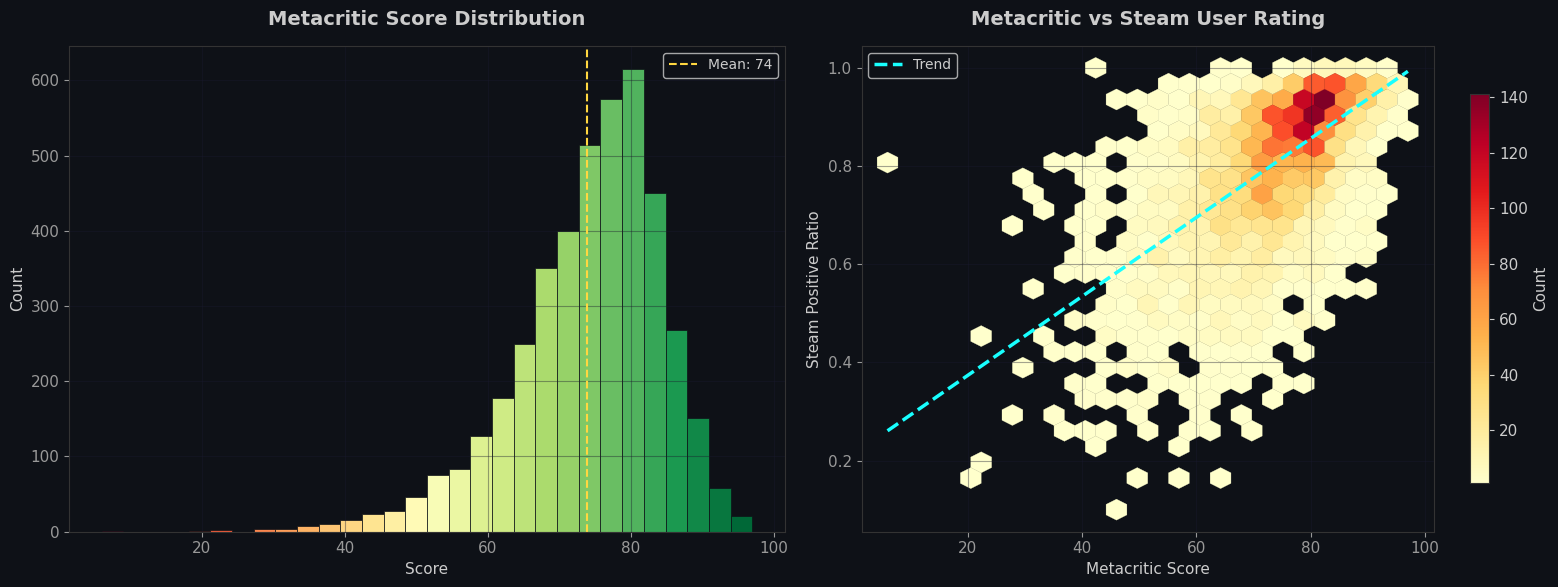

In [25]:
has_mc = df[df['Metacritic score'] > 0]
print(f'games with metacritic: {len(has_mc):,} ({len(has_mc)/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: metacritic distribution ---
n, bins, patches = axes[0].hist(has_mc['Metacritic score'], bins=30,
                                 edgecolor='#0e1117', linewidth=0.5)
cm = colormaps.get_cmap('RdYlGn')
for i, (patch, left_edge) in enumerate(zip(patches, bins[:-1])):
    norm_val = (left_edge - bins[0]) / (bins[-2] - bins[0])
    patch.set_facecolor(cm(norm_val))

axes[0].axvline(has_mc['Metacritic score'].mean(), color=COLORS['yellow'],
                linestyle='--', linewidth=1.5,
                label=f"Mean: {has_mc['Metacritic score'].mean():.0f}")
axes[0].set_title('Metacritic Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=10)

# --- right: metacritic vs steam user rating (hexbin) ---
both = has_mc[has_mc['has_reviews']].copy()
hb = axes[1].hexbin(both['Metacritic score'], both['positive_ratio'],
                     gridsize=25, cmap='YlOrRd', mincnt=1, linewidths=0.2)
# trend line
z = np.polyfit(both['Metacritic score'], both['positive_ratio'], 1)
p = np.poly1d(z)
x_line = np.linspace(both['Metacritic score'].min(), both['Metacritic score'].max(), 100)
axes[1].plot(x_line, p(x_line), color=COLORS['cyan'], linewidth=2.5, linestyle='--', label='Trend')
axes[1].set_xlabel('Metacritic Score')
axes[1].set_ylabel('Steam Positive Ratio')
axes[1].set_title('Metacritic vs Steam User Rating')
axes[1].legend(fontsize=10)
cb = plt.colorbar(hb, ax=axes[1], shrink=0.8, label='Count')
cb.ax.yaxis.set_tick_params(color='#cccccc')
plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='#cccccc')

plt.tight_layout()
plt.show()

## Language support

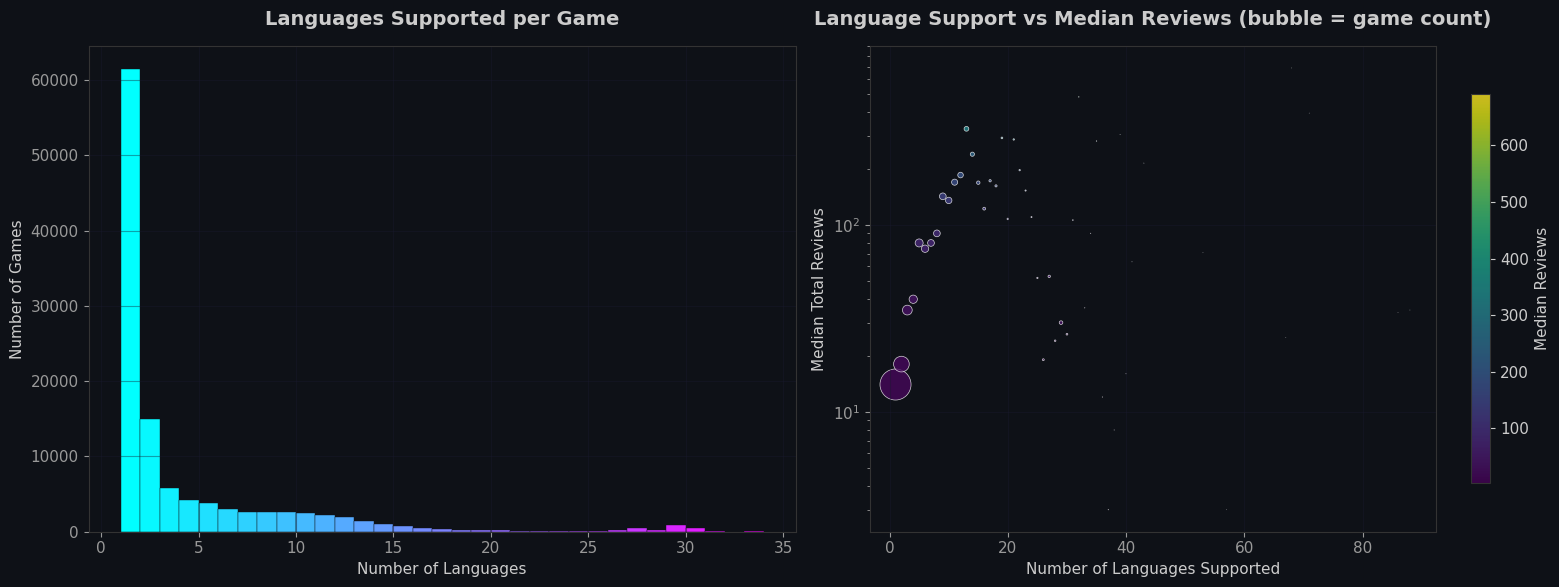

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: lang count distribution ---
lang_data = df['lang_count']
n, bins, patches = axes[0].hist(lang_data[lang_data > 0], bins=range(1, 35),
                                 edgecolor='#0e1117', linewidth=0.3)
cm = colormaps.get_cmap('cool')
for i, p in enumerate(patches):
    plt.setp(p, 'facecolor', cm(i/len(patches)))
axes[0].set_title('Languages Supported per Game')
axes[0].set_xlabel('Number of Languages')
axes[0].set_ylabel('Number of Games')

# --- right: language support vs median reviews (bubble chart) ---
lang_stats = df[df['has_reviews']].groupby('lang_count').agg(
    median_reviews=('total_reviews', 'median'),
    game_count=('total_reviews', 'size')
).reset_index()
lang_stats = lang_stats[lang_stats['lang_count'] > 0]

# bubble size proportional to game count
sizes = lang_stats['game_count'] / lang_stats['game_count'].max() * 500
scatter = axes[1].scatter(lang_stats['lang_count'], lang_stats['median_reviews'],
                          s=sizes, c=lang_stats['median_reviews'], cmap='viridis',
                          edgecolors='white', linewidth=0.5, alpha=0.8)
axes[1].set_xlabel('Number of Languages Supported')
axes[1].set_ylabel('Median Total Reviews')
axes[1].set_title('Language Support vs Median Reviews (bubble = game count)')
axes[1].set_yscale('log')
cb = plt.colorbar(scatter, ax=axes[1], shrink=0.8, label='Median Reviews')
cb.ax.yaxis.set_tick_params(color='#cccccc')
plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='#cccccc')

plt.tight_layout()
plt.show()

## Top developers and publishers

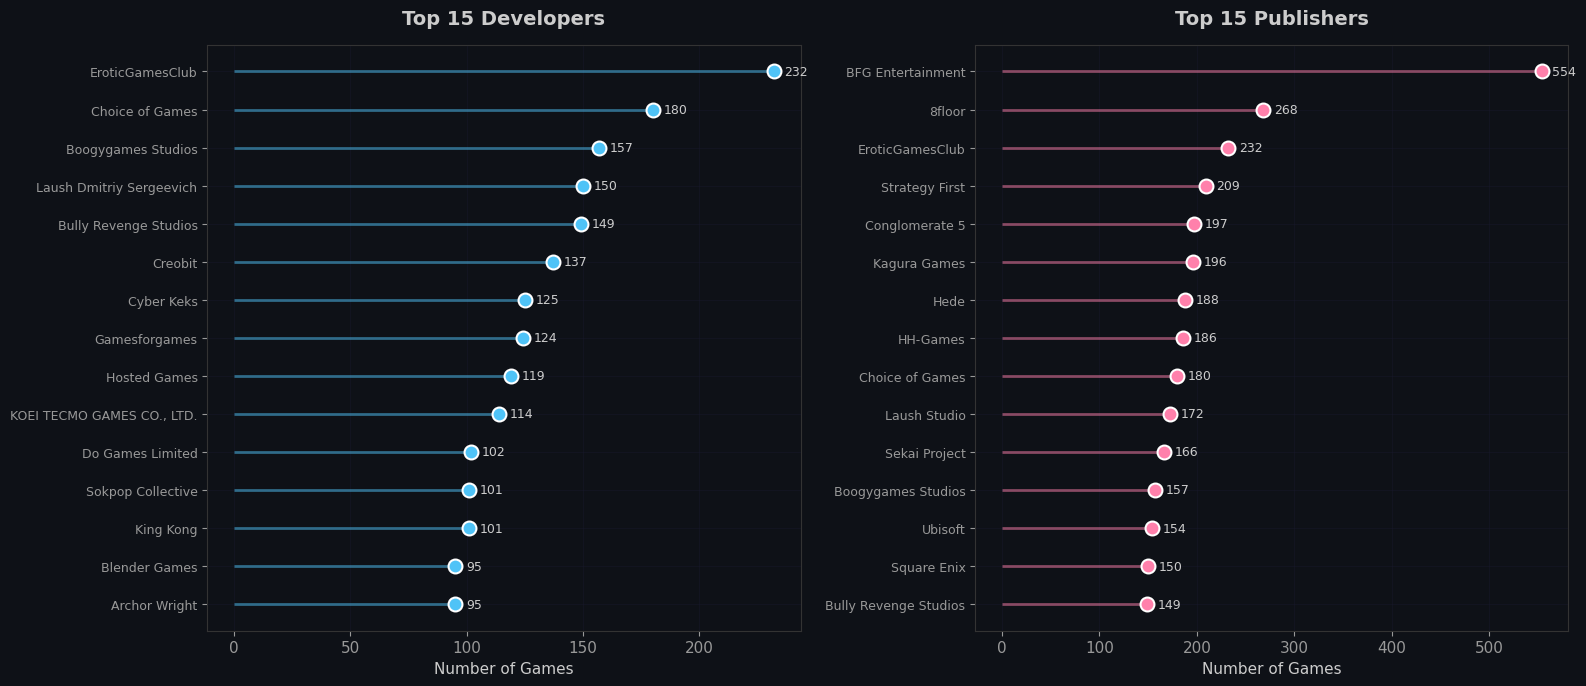

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- left: top devs (lollipop) ---
top_devs = df['Developers'].value_counts().head(15)
y = range(len(top_devs))
vals = top_devs.values[::-1]
labs = top_devs.index[::-1]

axes[0].hlines(y=y, xmin=0, xmax=vals, color=COLORS['blue'], alpha=0.5, linewidth=2)
axes[0].scatter(vals, y, color=COLORS['blue'], s=100, zorder=5,
                edgecolors='white', linewidth=1.5)
axes[0].set_yticks(y)
axes[0].set_yticklabels(labs, fontsize=9)
axes[0].set_title('Top 15 Developers')
axes[0].set_xlabel('Number of Games')
for i, v in enumerate(vals):
    axes[0].text(v + top_devs.max()*0.02, i, str(v), va='center', fontsize=9, color='#cccccc')

# --- right: top publishers (lollipop) ---
top_pubs = df['Publishers'].value_counts().head(15)
vals2 = top_pubs.values[::-1]
labs2 = top_pubs.index[::-1]

axes[1].hlines(y=y, xmin=0, xmax=vals2, color=COLORS['pink'], alpha=0.5, linewidth=2)
axes[1].scatter(vals2, y, color=COLORS['pink'], s=100, zorder=5,
                edgecolors='white', linewidth=1.5)
axes[1].set_yticks(y)
axes[1].set_yticklabels(labs2, fontsize=9)
axes[1].set_title('Top 15 Publishers')
axes[1].set_xlabel('Number of Games')
for i, v in enumerate(vals2):
    axes[1].text(v + top_pubs.max()*0.02, i, str(v), va='center', fontsize=9, color='#cccccc')

plt.tight_layout()
plt.show()

## Playtime analysis

games with playtime data: 26,173


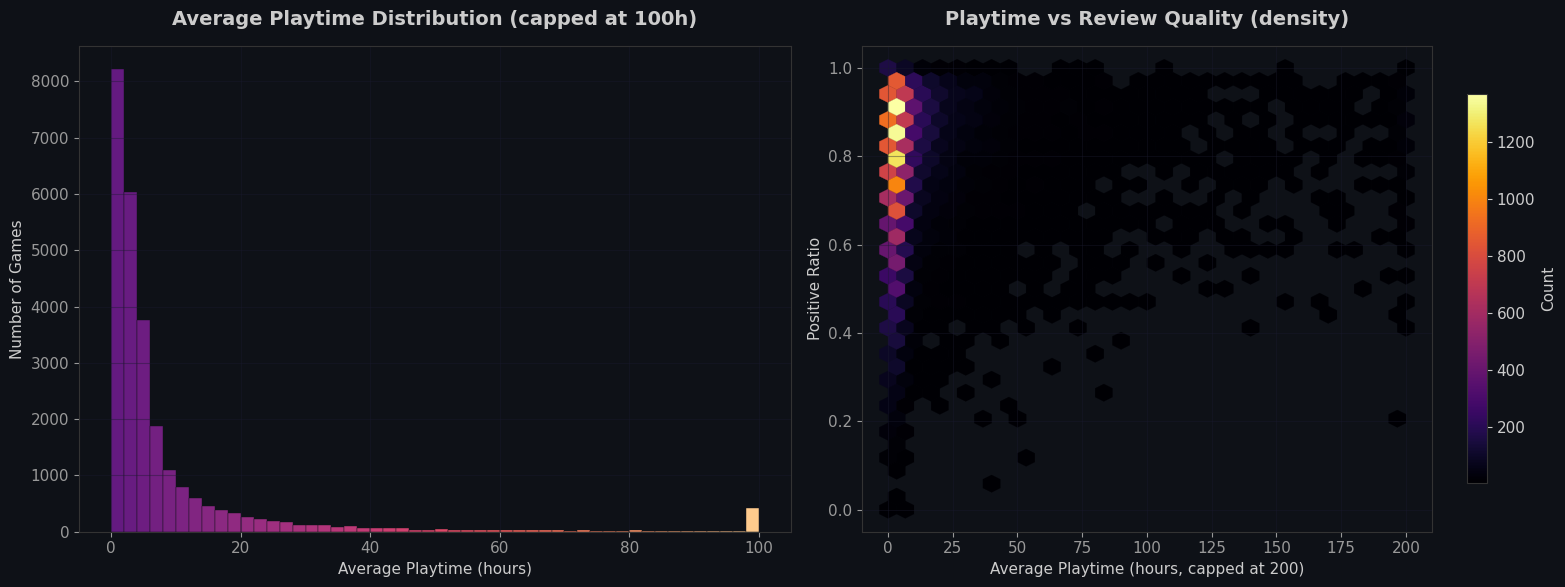

In [28]:
has_playtime = df[df['Average playtime forever'] > 0].copy()
has_playtime['avg_hours'] = has_playtime['Average playtime forever'] / 60
print(f'games with playtime data: {len(has_playtime):,}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: playtime distribution ---
hours_capped = has_playtime['avg_hours'].clip(upper=100)
n, bins, patches = axes[0].hist(hours_capped, bins=50, edgecolor='#0e1117', linewidth=0.3)
cm = colormaps.get_cmap('magma')
for i, p in enumerate(patches):
    plt.setp(p, 'facecolor', cm(0.3 + 0.6*i/len(patches)))
axes[0].set_title('Average Playtime Distribution (capped at 100h)')
axes[0].set_xlabel('Average Playtime (hours)')
axes[0].set_ylabel('Number of Games')

# --- right: playtime vs positive ratio (hexbin) ---
scatter_play = has_playtime[has_playtime['has_reviews']].copy()
hb = axes[1].hexbin(scatter_play['avg_hours'].clip(upper=200),
                     scatter_play['positive_ratio'], gridsize=30,
                     cmap='inferno', mincnt=1, linewidths=0.2)
axes[1].set_xlabel('Average Playtime (hours, capped at 200)')
axes[1].set_ylabel('Positive Ratio')
axes[1].set_title('Playtime vs Review Quality (density)')
cb = plt.colorbar(hb, ax=axes[1], shrink=0.8, label='Count')
cb.ax.yaxis.set_tick_params(color='#cccccc')
plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='#cccccc')

plt.tight_layout()
plt.show()

## Achievements

with achievements: 64,723 (51.4%)
without: 61,132
median reviews (with): 40
median reviews (without): 12


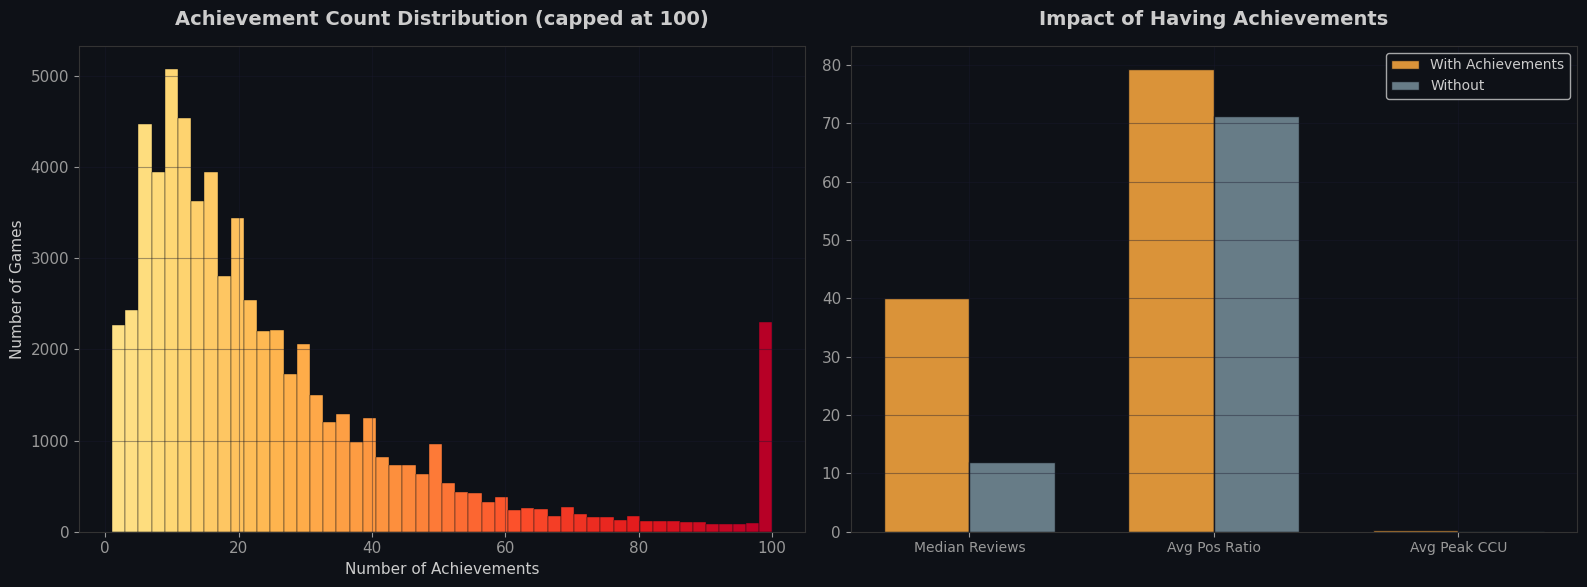

In [29]:
has_ach = df[df['Achievements'] > 0]
no_ach = df[df['Achievements'] == 0]

print(f'with achievements: {len(has_ach):,} ({len(has_ach)/len(df)*100:.1f}%)')
print(f'without: {len(no_ach):,}')
print(f'median reviews (with): {has_ach[has_ach["has_reviews"]]["total_reviews"].median():.0f}')
print(f'median reviews (without): {no_ach[no_ach["has_reviews"]]["total_reviews"].median():.0f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- left: achievement count distribution ---
ach_capped = has_ach['Achievements'].clip(upper=100)
n, bins, patches = axes[0].hist(ach_capped, bins=50, edgecolor='#0e1117', linewidth=0.3)
cm = colormaps.get_cmap('YlOrRd')
for i, p in enumerate(patches):
    plt.setp(p, 'facecolor', cm(0.2 + 0.7*i/len(patches)))
axes[0].set_title('Achievement Count Distribution (capped at 100)')
axes[0].set_xlabel('Number of Achievements')
axes[0].set_ylabel('Number of Games')

# --- right: with vs without achievements (grouped comparison) ---
has_ach_r = has_ach[has_ach['has_reviews']]
no_ach_r = no_ach[no_ach['has_reviews']]
metrics = ['Median Reviews', 'Avg Pos Ratio', 'Avg Peak CCU']
with_vals = [has_ach_r['total_reviews'].median(),
             has_ach_r['positive_ratio'].mean()*100,
             has_ach['Peak CCU'].mean()]
without_vals = [no_ach_r['total_reviews'].median(),
                no_ach_r['positive_ratio'].mean()*100,
                no_ach['Peak CCU'].mean()]

x = np.arange(len(metrics))
w = 0.35
axes[1].bar(x - w/2, with_vals, w, label='With Achievements',
            color=COLORS['orange'], edgecolor='#0e1117', alpha=0.85)
axes[1].bar(x + w/2, without_vals, w, label='Without',
            color=COLORS['gray'], edgecolor='#0e1117', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=10)
axes[1].set_title('Impact of Having Achievements')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## Owner distribution

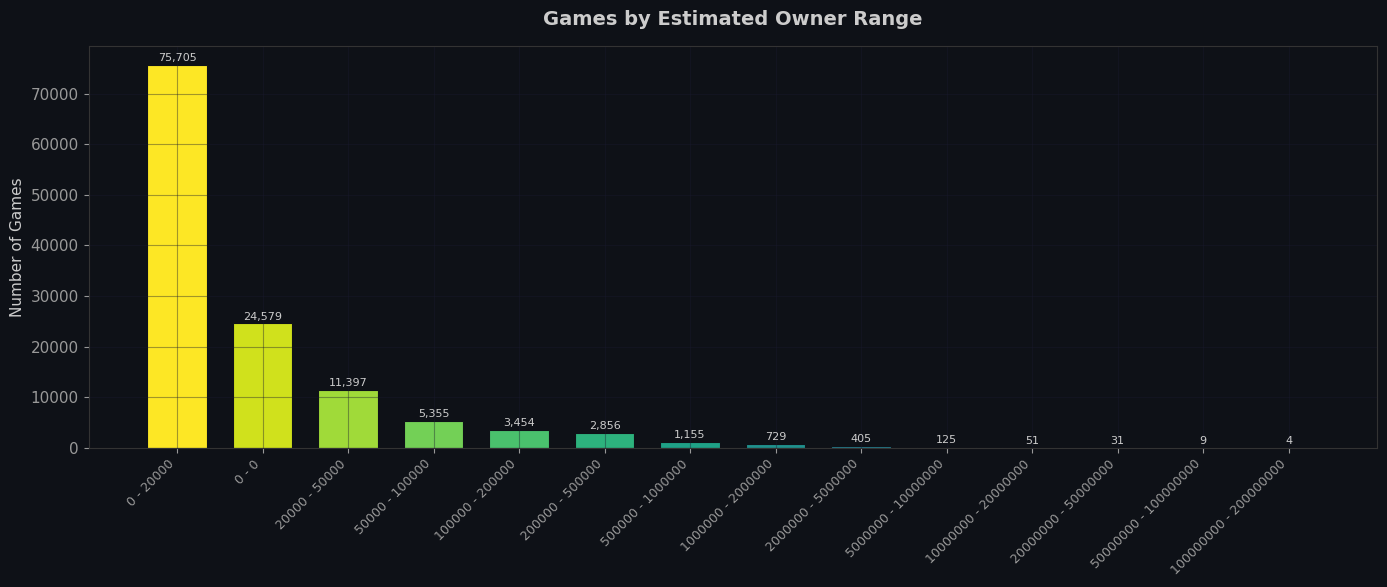

In [30]:
owner_dist = df['Owner Range'].value_counts()
# sort by the first number in the range
def sort_key(label):
    try:
        return int(str(label).split(' - ')[0].replace(',', ''))
    except:
        return 0

owner_dist = owner_dist.reindex(sorted(owner_dist.index, key=sort_key))

fig, ax = plt.subplots(figsize=(14, 6))

cm = colormaps.get_cmap('viridis_r')
bar_colors = [cm(i/len(owner_dist)) for i in range(len(owner_dist))]

bars = ax.bar(range(len(owner_dist)), owner_dist.values, color=bar_colors,
              edgecolor='#0e1117', linewidth=0.8, width=0.7)
ax.set_xticks(range(len(owner_dist)))
ax.set_xticklabels(owner_dist.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Games by Estimated Owner Range')
ax.set_ylabel('Number of Games')

for bar, val in zip(bars, owner_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + owner_dist.max()*0.01,
           f'{val:,}', ha='center', fontsize=8, color='#cccccc', rotation=0)

plt.tight_layout()
plt.show()

## Dashboard overview

putting some key metrics together in one view

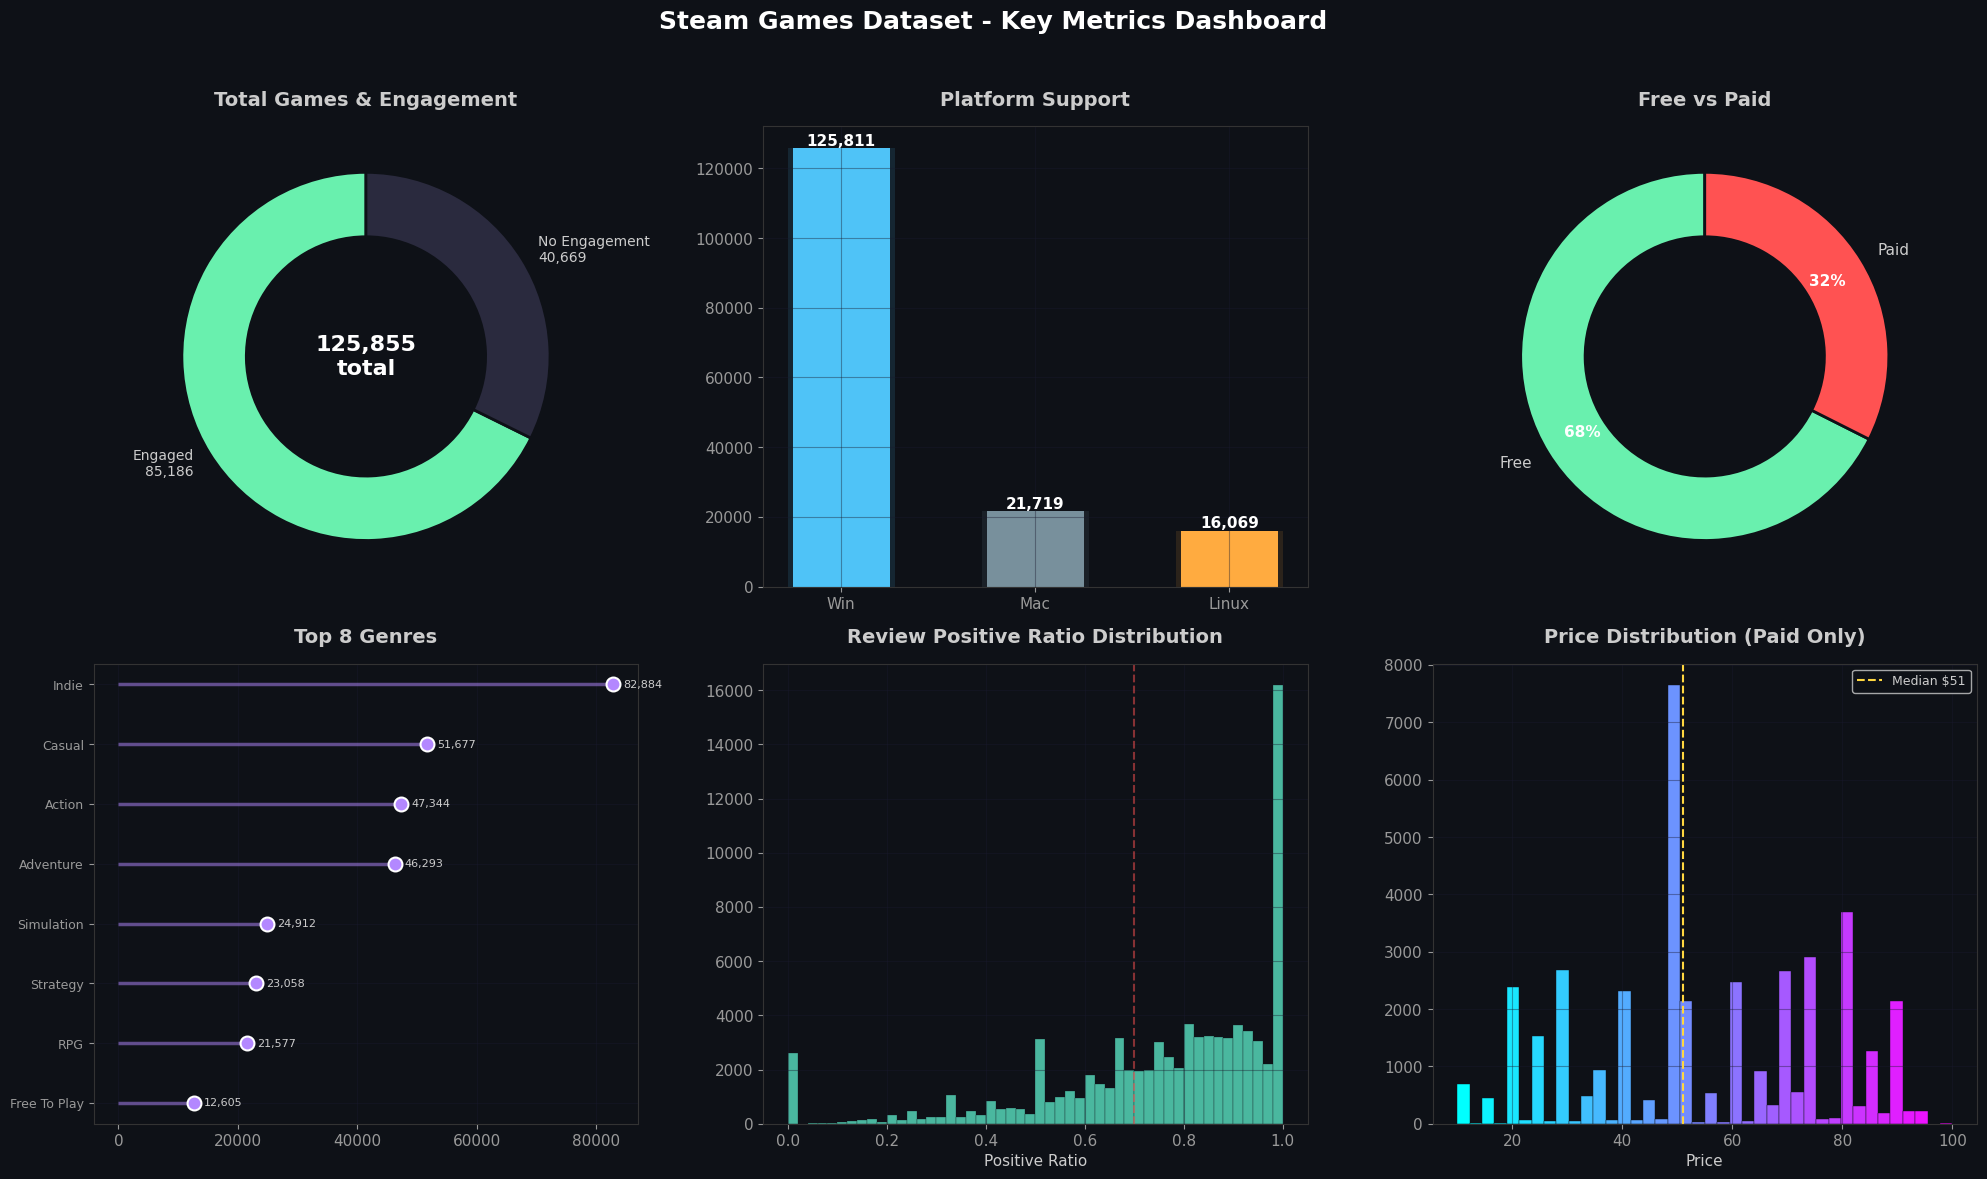

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Steam Games Dataset - Key Metrics Dashboard',
             fontsize=18, fontweight='bold', color='white', y=0.98)

# (0,0) - Total games donut with engagement breakdown
eng_counts = [engaged, not_engaged]
eng_labels = [f'Engaged\n{engaged:,}', f'No Engagement\n{not_engaged:,}']
wedges, texts = axes[0,0].pie(eng_counts, labels=eng_labels,
    colors=[COLORS['green'], '#2a2a3e'],
    wedgeprops=dict(width=0.35, edgecolor='#0e1117', linewidth=2),
    textprops={'color': '#cccccc', 'fontsize': 10}, startangle=90)
axes[0,0].text(0, 0, f'{len(df):,}\ntotal', ha='center', va='center',
               fontsize=16, fontweight='bold', color='white')
axes[0,0].set_title('Total Games & Engagement')

# (0,1) - Platform support bar
pdata = {'Win': df['Windows'].sum(), 'Mac': df['Mac'].sum(), 'Linux': df['Linux'].sum()}
pcols = [COLORS['blue'], COLORS['gray'], COLORS['orange']]
bars = axes[0,1].bar(pdata.keys(), pdata.values(), color=pcols, width=0.5, edgecolor='none')
for bar, color in zip(bars, pcols):
    axes[0,1].bar(bar.get_x() + bar.get_width()/2, bar.get_height(),
                  width=0.55, alpha=0.12, color=color, zorder=1)
for bar, val in zip(bars, pdata.values()):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+800,
                   f'{val:,}', ha='center', fontweight='bold', color='white', fontsize=11)
axes[0,1].set_title('Platform Support')

# (0,2) - Free vs Paid donut
wedges2, _, autotexts2 = axes[0,2].pie(
    [free_count, paid_count], labels=['Free', 'Paid'],
    autopct='%1.0f%%', colors=[COLORS['green'], COLORS['red']],
    startangle=90, wedgeprops=dict(width=0.35, edgecolor='#0e1117', linewidth=2),
    textprops={'color': '#cccccc', 'fontsize': 11}, pctdistance=0.78)
for at in autotexts2:
    at.set_color('white')
    at.set_fontweight('bold')
axes[0,2].set_title('Free vs Paid')

# (1,0) - Top 8 genres lollipop
gc = genre_counts.head(8)
y = range(len(gc))
v = gc.values[::-1]
l = gc.index[::-1]
axes[1,0].hlines(y=y, xmin=0, xmax=v, color=COLORS['purple'], alpha=0.5, linewidth=2.5)
axes[1,0].scatter(v, y, color=COLORS['purple'], s=100, zorder=5, edgecolors='white', linewidth=1.5)
axes[1,0].set_yticks(y)
axes[1,0].set_yticklabels(l, fontsize=9)
axes[1,0].set_title('Top 8 Genres')
for i, val in enumerate(v):
    axes[1,0].text(val + gc.max()*0.02, i, f'{val:,}', va='center', fontsize=8, color='#cccccc')

# (1,1) - Review ratio distribution
axes[1,1].hist(reviewed['positive_ratio'].dropna(), bins=50,
               color=COLORS['teal'], edgecolor='#0e1117', linewidth=0.3, alpha=0.7)
axes[1,1].axvline(0.7, color=COLORS['red'], linestyle='--', alpha=0.5, linewidth=1.5)
axes[1,1].set_title('Review Positive Ratio Distribution')
axes[1,1].set_xlabel('Positive Ratio')

# (1,2) - Price distribution (paid only)
n, bins, patches = axes[1,2].hist(paid_prices, bins=40, edgecolor='#0e1117', linewidth=0.3)
cm = colormaps.get_cmap('cool')
for i, p in enumerate(patches):
    plt.setp(p, 'facecolor', cm(i/len(patches)))
axes[1,2].set_title('Price Distribution (Paid Only)')
axes[1,2].set_xlabel('Price')
axes[1,2].axvline(paid_prices.median(), color=COLORS['yellow'], linestyle='--',
                  linewidth=1.5, label=f'Median ${paid_prices.median():.0f}')
axes[1,2].legend(fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Key Insights

after going through all of this, here are the things that stood out to me:

### 1. The Invisible Majority
this is the biggest thing. most games on steam have essentially zero engagement - no reviews, no players, nothing. the 75th percentile for estimated owners is 0. that means over 75% of games on steam might as well not exist. steam has a massive discovery problem and most games that get published there just vanish into the void.

### 2. The 1% Rule
the lorenz curve says it all. the top 1% of games get the vast majority of all reviews. this is a classic power law distribution - the gaming market is winner-take-all. a handful of mega-hits dominate everything while tens of thousands of games sit with single digit reviews.

### 3. Free doesnt mean bad
free games actually get more engagement and comparable review quality to paid games. the positive ratio is similar between free and paid. this challenges the assumption that free = low quality.

### 4. Price has almost no correlation with quality
the hexbin plots of price vs positive ratio are basically uniform blobs. expensive games arent necessarily better-reviewed than cheap ones. there is zero meaningful correlation.

### 5. Indie dominance
indie is by far the most common genre/tag. steam is absolutely flooded with indie games. this ties back to the invisible majority - most of these indie games are the ones getting zero engagement.

### 6. Metacritic is mostly irrelevant
only ~3.4% of games have a metacritic score. but for games that DO have both, there is a positive correlation between metacritic and steam user ratings.

### 7. Language support matters
the bubble chart shows a clear positive relationship between languages supported and reviews received. games with 10+ languages get dramatically more reviews. localization seems to be a real driver of reach.

### 8. Achievements boost engagement
games with achievements get significantly more reviews. whether achievements cause engagement or popular games just tend to add them is unclear, but the correlation is strong.

### 9. Data quality issues
this dataset has quirks. the release date and estimated owners columns seem swapped. two columns are completely empty. the reviews text is 90% missing.

### 10. Windows is the only platform that matters (for now)
99.9% of games support windows. mac is at 17%, linux at 13%. the ~13% linux support is actually higher than i expected.

---
thats it for now. some ideas for next steps:
- sentiment analysis on the review text (for the 10% that has it)
- time series analysis if we can fix the date column
- genre clustering to find which genre combos are most successful
- predicting game success from features available at launch